[![Open In Colab](https://sec-api.io/media/colab-badge.svg)](https://colab.research.google.com/github/SEC-API-io/sec-api-cookbook/blob/main/notebooks/form-13d-13g/form-13d-13g-api-examples.ipynb)
[![View on GitHub](https://sec-api.io/media/view-on-github-badge.svg)](https://github.com/SEC-API-io/sec-api-cookbook/blob/main/notebooks/form-13d-13g/form-13d-13g-api-examples.ipynb)

# Analyzing Beneficial Ownership with SEC Form 13D/13G Data

When an investor acquires more than 5% of a publicly traded company's equity securities, they must disclose that position to the SEC by filing a Schedule 13D or Schedule 13G. These filings are among the most closely watched documents in financial markets — they reveal which major investors are building stakes, how large those stakes are, and (in the case of Schedule 13D) what the investor intends to do with their position.

This notebook shows how to use the [sec-api.io](https://sec-api.io) Form 13D/13G API to query, filter, and analyze beneficial ownership data. We will cover querying filings by owner name, CUSIP, form type, and date range; normalizing the nested JSON responses into pandas DataFrames; computing summary statistics; and visualizing ownership patterns. The API provides coverage from 1994 to the present with real-time updates as new filings hit EDGAR.

By the end of this tutorial you will be able to programmatically retrieve 13D/13G data, identify large block holders in any public company, and build analytical workflows around beneficial ownership disclosures.

## Regulatory Background

### Who Must File

Sections 13(d) and 13(g) of the Securities Exchange Act of 1934 (15 U.S.C. §§ 78m(d), 78m(g)) require any person or group that acquires beneficial ownership of more than 5% of a class of equity securities registered under Section 12 to file a disclosure statement with the SEC. Under Rule 13d-3 (17 CFR § 240.13d-3), "beneficial ownership" means having voting power (the power to vote or direct the voting of the security) or investment power (the power to dispose of or direct the disposition of the security). This includes shares held through trusts, by family members in the same household, and shares acquirable within 60 days through options, warrants, or conversion rights.

### Schedule 13D vs. Schedule 13G

**Schedule 13D** is the "long form" disclosure required of any beneficial owner above the 5% threshold who does not qualify for the short form. It requires detailed disclosure of the investor's identity, source of funds, purpose of the transaction, and any plans that could result in corporate changes (mergers, board changes, etc.).

**Schedule 13G** is a streamlined alternative available to three categories of investors:

- **Qualified Institutional Investors (QIIs)** under Rule 13d-1(b): broker-dealers, banks, insurance companies, registered investment companies, and registered investment advisers that acquired shares in the ordinary course of business without a control purpose.
- **Passive investors** under Rule 13d-1(c): any person who beneficially owns more than 5% but less than 20% and did not acquire with the purpose or effect of changing or influencing control.
- **Exempt investors** under Rule 13d-1(d): persons who held more than 5% before the class was registered under Section 12.

### Filing Deadlines (Post-2024 Amendments)

In October 2023, the SEC adopted Release No. 33-11253, modernizing beneficial ownership reporting. Key deadline changes (compliance dates: September 30, 2024 for deadlines; December 18, 2024 for structured data):

| Filing | Old Deadline | New Deadline |
|--------|-------------|--------------|
| 13D initial | 10 calendar days | **5 business days** |
| 13D amendment | "Promptly" | **2 business days** |
| 13G QII/exempt initial | 45 days after year-end | **45 days after quarter-end** |
| 13G passive initial | 10 calendar days | **5 business days** |
| 13G QII amendment (>10%) | 10 days after month-end | **5 business days after month-end** |

### Structured Data & Other 2023 Changes

The 2023 amendments also required all Schedule 13D and 13G filings to be submitted in structured XML format (effective December 18, 2024), mandated disclosure of cash-settled derivative securities (including total return swaps) in Item 6 of Schedule 13D, and extended the EDGAR filing window from 5:30 p.m. ET to 10:00 p.m. ET.

## Environment Setup

Install the `sec-api` package and import the libraries we will use throughout this notebook. You will need an API key from [sec-api.io](https://sec-api.io).

In [ ]:
%pip install sec-api -q

In [ ]:
from sec_api import Form13DGApi
import pandas as pd
import json
import matplotlib.pyplot as plt

pd.options.display.float_format = lambda v: f"{v:,.2f}"
pd.options.display.max_columns = 50
pd.options.display.width = 200

API_KEY = "YOUR_API_KEY"
form13DGApi = Form13DGApi(API_KEY)

## Querying 13D/13G Filings

The Form 13D/13G API accepts a JSON query object with four parameters:

- **`query`** — a Lucene query string that filters filings by any combination of fields (e.g., `formType`, `owners.name`, `cusip`, `filedAt`).
- **`from`** — the starting offset for pagination (zero-based).
- **`size`** — the number of results to return per request (maximum 50).
- **`sort`** — an array of field/order pairs controlling result ordering.

The API returns an object with `total` (the count of matching filings) and `filings` (the array of results for this page). Let's start with a simple query that retrieves the 50 most recent Schedule 13D filings.

In [2]:
query = {
    "query": 'formType:"SC 13D"',
    "from": "0",
    "size": "50",
    "sort": [{"filedAt": {"order": "desc"}}]
}

response = form13DGApi.get_data(query)

print(f"Total matching filings: {response['total']}")
print(f"Filings returned: {len(response['filings'])}")
print()
print("First filing (sample):")
print(json.dumps(response["filings"][0], indent=2))

Total matching filings: {'value': 10000, 'relation': 'gte'}
Filings returned: 50

First filing (sample):
{
  "id": "8237e891c3308cd3ae3ec74553516edf",
  "accessionNo": "0000950103-26-005722",
  "formType": "SC 13D/A",
  "filedAt": "2026-04-15T06:19:05-04:00",
  "filers": [
    {
      "cik": "1014763",
      "name": "Ainos, Inc. (Subject)"
    },
    {
      "cik": "1122411",
      "name": "ASE Technology Holding Co., Ltd. (Filed by)"
    }
  ],
  "nameOfIssuer": "Ainos, Inc.",
  "titleOfSecurities": "Common Stock, par value $0.01 per share",
  "cusip": [],
  "eventDate": "2026-04-12",
  "amendmentNo": "2",
  "schedule13GFiledPreviously": false,
  "owners": [
    {
      "name": [
        "ASE Technology Holding Co., Ltd."
      ],
      "memberOfGroup": {
        "a": false,
        "b": false
      },
      "sourceOfFunds": "WC",
      "legalProceedingsDisclosureRequired": false,
      "place": "F5",
      "soleVotingPower": 0,
      "sharedVotingPower": 667085,
      "soleDispositiv

### Understanding the Response Structure

Each filing in the `filings` array contains a rich set of fields organized into several groups:

**Core fields:** `id` (unique identifier), `accessionNo` (SEC accession number), `formType` (one of `"SC 13D"`, `"SC 13D/A"`, `"SC 13G"`, `"SC 13G/A"`), `filedAt` (timestamp), and `filers` (array with CIK and name for both the Subject company and the Filing entity).

**Issuer fields:** `nameOfIssuer`, `titleOfSecurities`, `cusip` (array of CUSIP identifiers), and `eventDate` (the date of the event triggering the filing).

**Owners array:** Each element in the `owners` array represents a reporting person and includes:
- `name`, `place` — identity and jurisdiction
- `sourceOfFunds` — array of fund-source codes: **AF** (Affiliate), **BK** (Bank), **OO** (Other), **PF** (Personal Funds), **SC** (Subject Company), **WC** (Working Capital)
- `soleVotingPower`, `sharedVotingPower`, `soleDispositivePower`, `sharedDispositivePower` — the breakdown of voting and investment power over the securities
- `aggregateAmountOwned`, `amountAsPercent` — total shares and percentage of class owned
- `typeOfReportingPerson` — array of codes: **BD** (Broker-Dealer), **BK** (Bank), **IC** (Insurance Company), **IV** (Investment Company), **IA** (Investment Adviser), **IN** (Individual), **PN** (Partnership), **HC** (Holding Company), **OO** (Other)
- `memberOfGroup` — whether the reporting person is part of a 13D group (sub-fields `a` and `b`)

**Item-level structured data (Schedule 13D):** Fields `item1` through `item7` map to the items on the Schedule 13D form. Notable examples include `item4.transactionPurpose` (the filer's stated purpose — critical for activism analysis) and `item6.contractDescription` (derivative securities arrangements).

**Item-level structured data (Schedule 13G):** Includes `applicableRule.13d-1b`, `applicableRule.13d-1c`, and `applicableRule.13d-1d` — boolean fields identifying which regulatory category the filer claims (QII, passive, or exempt, respectively). Fields `item1` through `item10` provide the structured schedule data.

> **Note on array fields:** Fields like `cusip`, `sourceOfFunds`, and `typeOfReportingPerson` are arrays. Lucene queries match against any element in the array, so `owners.typeOfReportingPerson:IC` will match filings where at least one owner has type IC.

In [3]:
# Flatten the nested JSON into a tabular format
df_recent = pd.json_normalize(response["filings"], sep="_")

# Select key columns for display
display_cols = [
    "accessionNo", "formType", "filedAt", "nameOfIssuer",
    "titleOfSecurities"
]
available_cols = [c for c in display_cols if c in df_recent.columns]
df_recent[available_cols].head(10)

,accessionNo,formType,filedAt,nameOfIssuer,titleOfSecurities
0,0000950103-26-005722,SC 13D/A,2026-04-15T06:19:05-04:00,"Ainos, Inc.","Common Stock, par value $0.01 per share"
1,0000899140-26-000385,SC 13D,2026-04-14T21:54:52-04:00,Third Point Private Capital Partners,"Class I Common Shares, par value $0.001 per share"
2,0001104659-26-043404,SC 13D/A,2026-04-14T21:47:19-04:00,"Getaround, Inc","Common Stock, par value $0.0001 per share"
3,0001104659-26-043389,SC 13D/A,2026-04-14T21:00:08-04:00,Absci Corporation,"Common Stock, $0.0001 par value per share"
4,0001062993-26-001986,SC 13D/A,2026-04-14T19:59:57-04:00,Highland Opportunities and Income Fund,"Common Shares, $0.001 par value"
5,0001193125-26-155387,SC 13D/A,2026-04-14T19:58:27-04:00,GeoPark Limited,"Common Shares, par value $0.001 per share"
6,0000921895-26-000986,SC 13D/A,2026-04-14T18:01:39-04:00,FOSTER L B CO,"Common Stock, par value $0.01 per share"
7,0001193125-26-155180,SC 13D/A,2026-04-14T17:45:02-04:00,lululemon athletica inc.,Common Stock
8,0001062993-26-001981,SC 13D/A,2026-04-14T17:35:25-04:00,"The New Germany Fund, Inc.","Common Shares, $0.001 par value"
9,0001437749-26-012268,SC 13D/A,2026-04-14T17:19:06-04:00,PRIMEENERGY RESOURCES CORP,"Common Stock, $0.10 par value"


## Filtering by Owner Name and Ownership Percentage

You can search for filings by a specific owner using the `owners.name` field in the Lucene query. Combine this with a range query on `owners.amountAsPercent` to find only filings where the owner holds a significant stake. Range queries use the syntax `[lower TO upper]`, where `*` represents an unbounded end.

In [4]:
# Find filings where Point72 entities own 10% or more
query = {
    "query": "owners.name:Point72 AND owners.amountAsPercent:[10 TO *]",
    "from": "0",
    "size": "50",
    "sort": [{"filedAt": {"order": "desc"}}]
}

response_point72 = form13DGApi.get_data(query)
print(f"Total matching filings: {response_point72['total']}")

df_point72 = pd.json_normalize(response_point72["filings"], sep="_")
point72_cols = ["accessionNo", "formType", "filedAt", "nameOfIssuer"]
available_cols = [c for c in point72_cols if c in df_point72.columns]
df_point72[available_cols]

Total matching filings: {'value': 8, 'relation': 'eq'}


,accessionNo,formType,filedAt,nameOfIssuer
0,0000902664-22-005029,SC 13D,2022-12-05T16:00:20-05:00,"Tempo Automation Holdings, Inc."
1,0000899140-21-000280,SC 13G/A,2021-02-16T15:09:09-05:00,
2,0000899140-18-000352,SC 13D/A,2018-04-25T17:21:29-04:00,"LAUREATE EDUCATION, INC."
3,0000899140-18-000308,SC 13D,2018-03-20T16:54:27-04:00,"BUILD-A-BEAR WORKSHOP, INC."
4,0000899140-18-000223,SC 13G/A,2018-02-14T14:58:57-05:00,
5,0000899140-18-000028,SC 13D/A,2018-01-05T17:22:57-05:00,LAUREATE EDUCATION INC.
6,0001193125-17-057741,SC 13G,2017-02-27T09:02:05-05:00,"BUILD-A-BEAR WORKSHOP, INC."
7,0000899140-17-000275,SC 13D,2017-02-16T17:07:52-05:00,LAUREATE EDUCATION INC.


## Searching by CUSIP

The `cusip` field lets you track all beneficial ownership filings for a specific security, regardless of issuer name changes or ticker symbol changes. CUSIP (Committee on Uniform Securities Identification Procedures) is a 9-character alphanumeric code that uniquely identifies a security. This is especially useful for tracking ownership history over time.

In [5]:
# Search for 13D/13G filings related to Apple Inc. (CUSIP: 037833100)
query = {
    "query": "cusip:037833100",
    "from": "0",
    "size": "50",
    "sort": [{"filedAt": {"order": "desc"}}]
}

response_cusip = form13DGApi.get_data(query)
print(f"Total filings for CUSIP 037833100 (Apple Inc.): {response_cusip['total']}")

df_cusip = pd.json_normalize(response_cusip["filings"], sep="_")
cusip_cols = ["accessionNo", "formType", "filedAt", "nameOfIssuer"]
available_cols = [c for c in cusip_cols if c in df_cusip.columns]
df_cusip[available_cols].head(10)

Total filings for CUSIP 037833100 (Apple Inc.): {'value': 69, 'relation': 'eq'}


,accessionNo,formType,filedAt,nameOfIssuer
0,0000932471-25-000778,SC 13G/A,2025-07-29T11:22:01-04:00,Apple Inc
1,0001193125-24-036431,SC 13G/A,2024-02-14T16:47:05-05:00,APPLE INC.
2,0001104659-24-020009,SC 13G/A,2024-02-13T16:55:49-05:00,Apple Inc
3,0001086364-24-006980,SC 13G/A,2024-02-12T16:17:19-05:00,APPLE INC
4,0001193125-23-038262,SC 13G/A,2023-02-14T12:47:31-05:00,APPLE INC.
5,0001104659-23-015055,SC 13G/A,2023-02-09T10:54:46-05:00,Apple Inc.
6,0001306550-23-008266,SC 13G/A,2023-02-07T14:10:46-05:00,APPLE INC
7,0001104659-22-016224,SC 13G/A,2022-02-09T15:16:02-05:00,Apple Inc.
8,0000834237-22-004076,SC 13G/A,2022-01-31T17:59:30-05:00,APPLE INC
9,0001193125-21-044816,SC 13G/A,2021-02-16T16:02:01-05:00,APPLE INC.


## Comparing 13D and 13G Filings

You can filter filings by `formType` to focus on a specific schedule or its amendments. The four form type values are `"SC 13D"`, `"SC 13D/A"` (amendment), `"SC 13G"`, and `"SC 13G/A"` (amendment).

Several fields in the response are arrays — for example, `typeOfReportingPerson`, `cusip`, and `sourceOfFunds`. When you query an array field, Lucene matches against any element in the array. So `owners.typeOfReportingPerson:IC` returns filings where at least one reporting person is an insurance company, even if other owners on the same filing have different types.

Schedule 13G filings also include the `applicableRule` boolean fields: `applicableRule.13d-1b` (Qualified Institutional Investor), `applicableRule.13d-1c` (passive investor), and `applicableRule.13d-1d` (exempt investor). These correspond to the three regulatory categories described in the background section and let you filter 13G filings by the category the filer claims.

In [6]:
# Find Schedule 13G filings where at least one owner is an insurance company (IC)
query = {
    "query": 'formType:"SC 13G" AND owners.typeOfReportingPerson:IC',
    "from": "0",
    "size": "50",
    "sort": [{"filedAt": {"order": "desc"}}]
}

response_ic = form13DGApi.get_data(query)
print(f"Total 13G filings with insurance company owners: {response_ic['total']}")

df_ic = pd.json_normalize(response_ic["filings"], sep="_")
ic_cols = ["accessionNo", "formType", "filedAt", "nameOfIssuer"]
available_cols = [c for c in ic_cols if c in df_ic.columns]
df_ic[available_cols].head(10)

Total 13G filings with insurance company owners: {'value': 10000, 'relation': 'gte'}


,accessionNo,formType,filedAt,nameOfIssuer
0,0001193125-26-138205,SC 13G,2026-04-01T17:13:12-04:00,Sound Point Direct Lending BDC
1,0001193125-26-137792,SC 13G/A,2026-04-01T15:47:07-04:00,Willow Tree Capital Corporation
2,0001104659-26-038248,SC 13G/A,2026-04-01T08:33:24-04:00,"HYPERION DEFI, INC."
3,0000903939-26-000020,SC 13G/A,2026-03-31T15:00:30-04:00,Privacore VPC Asset Backed Credit Fund
4,0001193125-26-123358,SC 13G,2026-03-25T12:15:42-04:00,Carlyle Tactical Private Credit Fund
5,0001193125-26-096046,SC 13G/A,2026-03-06T14:00:02-05:00,ICON plc
6,0001140361-26-008176,SC 13G/A,2026-03-06T08:39:52-05:00,FS Credit Opportunities Corp.
7,0001104659-26-022459,SC 13G/A,2026-03-03T06:00:30-05:00,"HYPERION DEFI, INC."
8,0000903939-26-000013,SC 13G/A,2026-03-02T16:11:09-05:00,Privacore VPC Asset Backed Credit Fund
9,0001193125-26-054685,SC 13G,2026-02-17T16:15:24-05:00,"LIBERTY LIVE HOLDINGS, INC."


In [7]:
# Find Schedule 13G filings by Qualified Institutional Investors (Rule 13d-1(b))
query = {
    "query": 'formType:"SC 13G" AND applicableRule.13d-1b:true',
    "from": "0",
    "size": "50",
    "sort": [{"filedAt": {"order": "desc"}}]
}

response_qii = form13DGApi.get_data(query)
print(f"Total 13G filings by QIIs (Rule 13d-1(b)): {response_qii['total']}")

df_qii = pd.json_normalize(response_qii["filings"], sep="_")
qii_cols = ["accessionNo", "formType", "nameOfIssuer"]
available_cols = [c for c in qii_cols if c in df_qii.columns]
df_qii[available_cols].head(10)

Total 13G filings by QIIs (Rule 13d-1(b)): {'value': 10000, 'relation': 'gte'}


,accessionNo,formType,nameOfIssuer
0,0001442181-26-000008,SC 13G/A,Sanara MedTech Inc.
1,0000898358-26-000004,SC 13G/A,LANDMARK BANCORP INC
2,0000810972-26-000028,SC 13G,"T. Rowe Price Exchange-Traded Funds, Inc."
3,0001019432-26-000007,SC 13G/A,Maris Tech Ltd.
4,0001890906-26-000039,SC 13G/A,Total Return Securities Fund
5,0001890906-26-000038,SC 13G/A,Stewart Information Services C
6,0001890906-26-000037,SC 13G/A,Quanex Building Products Corp
7,0001890906-26-000036,SC 13G/A,Pursuit Attractions and Hospit
8,0001890906-26-000035,SC 13G/A,Gates Industrial Corp PLC
9,0001890906-26-000034,SC 13G/A,European Equity Fund Inc/The


## Filtering by Filing Date

Use a range query on the `filedAt` field to retrieve filings within a specific date range. The Lucene date-range syntax is `filedAt:[YYYY-MM-DD TO YYYY-MM-DD]`. This is useful for analyzing filing activity during a particular period — for example, filings submitted after the September 30, 2024 compliance date for the modernized Schedule 13G deadlines.

In [8]:
# Retrieve Schedule 13D filings from 2024
query = {
    "query": 'formType:"SC 13D" AND filedAt:[2024-01-01 TO 2024-12-31]',
    "from": "0",
    "size": "50",
    "sort": [{"filedAt": {"order": "desc"}}]
}

response_2024 = form13DGApi.get_data(query)
print(f"Total 13D filings in 2024: {response_2024['total']}")

df_2024 = pd.json_normalize(response_2024["filings"], sep="_")
date_cols = ["accessionNo", "formType", "filedAt", "nameOfIssuer"]
available_cols = [c for c in date_cols if c in df_2024.columns]
df_2024[available_cols].head(10)

Total 13D filings in 2024: {'value': 6022, 'relation': 'eq'}


,accessionNo,formType,filedAt,nameOfIssuer
0,0001104659-24-132991,SC 13D/A,2024-12-31T21:42:00-05:00,AMC Networks Inc.
1,0001104659-24-132989,SC 13D/A,2024-12-31T21:26:00-05:00,Madison Square Garden Sports Corp.
2,0001104659-24-132988,SC 13D/A,2024-12-31T21:13:54-05:00,Madison Square Garden Entertainment Corp.
3,0001104659-24-132987,SC 13D/A,2024-12-31T21:12:48-05:00,Sphere Entertainment Co.
4,0000950170-24-141714,SC 13D,2024-12-31T21:12:20-05:00,"FREYR Battery, Inc."
5,0001213900-24-114227,SC 13D/A,2024-12-31T21:12:17-05:00,"Bolt Projects Holdings, Inc."
6,0000950170-24-141713,SC 13D/A,2024-12-31T21:00:14-05:00,ProFrac Holding Corp.
7,0001140361-24-050720,SC 13D/A,2024-12-31T20:30:05-05:00,Quantum-Si Inc
8,0000950142-24-003049,SC 13D/A,2024-12-31T18:49:03-05:00,TERAWULF INC.
9,0001104659-24-132953,SC 13D/A,2024-12-31T18:48:20-05:00,"Southland Holdings, Inc."


## Pagination: Retrieving Large Result Sets

The API returns a maximum of 50 filings per request. To retrieve more results, increment the `from` parameter in a loop. The `total` field in the response tells you how many filings match your query, so you know when to stop.

In [9]:
def fetch_all_filings(query_str, max_filings=200):
    """Fetch up to max_filings by paginating through the API."""
    all_filings = []
    page_size = 50
    offset = 0

    while offset < max_filings:
        query = {
            "query": query_str,
            "from": str(offset),
            "size": str(page_size),
            "sort": [{"filedAt": {"order": "desc"}}]
        }
        response = form13DGApi.get_data(query)
        filings = response.get("filings", [])

        if not filings:
            break

        all_filings.extend(filings)
        offset += page_size

        total = response["total"]["value"] if isinstance(response["total"], dict) else response["total"]
        if offset >= total:
            break

    print(f"Fetched {len(all_filings)} filings (query: {query_str[:60]}...)")
    return all_filings

## Aggregation and Statistics

With a larger dataset we can compute meaningful statistics: how filings break down across form types, which issuers attract the most ownership disclosures, and how ownership percentages are distributed. Let's use the pagination helper to fetch a broad sample of recent 13D and 13G filings.

In [10]:
# Fetch up to 200 recent filings across all 13D/13G form types
all_filings = fetch_all_filings(
    'formType:("SC 13D" OR "SC 13G" OR "SC 13D/A" OR "SC 13G/A")',
    max_filings=200
)

df = pd.json_normalize(all_filings, sep="_")
print(f"DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns[:15])}...")
df.head(5)

Fetched 200 filings (query: formType:("SC 13D" OR "SC 13G" OR "SC 13D/A" OR "SC 13G/A")...)
DataFrame shape: (200, 61)
Columns: ['id', 'accessionNo', 'formType', 'filedAt', 'filers', 'nameOfIssuer', 'titleOfSecurities', 'cusip', 'eventDate', 'amendmentNo', 'owners', 'applicableRule_13d-1b', 'applicableRule_13d-1c', 'applicableRule_13d-1d', 'item1_issuerName']...


,id,accessionNo,formType,filedAt,filers,nameOfIssuer,titleOfSecurities,cusip,eventDate,amendmentNo,owners,applicableRule_13d-1b,applicableRule_13d-1c,applicableRule_13d-1d,item1_issuerName,item1_issuerPrincipalExecutiveOfficeAddress,item2_filingPersonName,item2_principalBusinessOfficeOrResidenceAddress,item2_citizenship,item3_notApplicable,item3_typeOfPersonFiling,item3_otherTypeOfPersonFiling,item4_amountBeneficiallyOwned,item4_classPercent,item4_numberOfSharesPersonHas_solePowerOrDirectToVote,...,item9_notApplicable,item9_groupDissolutionNotice,item10_notApplicable,item10_certifications,schedule13GFiledPreviously,item1_securityTitle,item1_issuerPrincipalAddress_street1,item1_issuerPrincipalAddress_street2,item1_issuerPrincipalAddress_city,item1_issuerPrincipalAddress_stateOrCountry,item1_issuerPrincipalAddress_zipCode,item1_commentText,item2_principalBusinessAddress,item2_principalJob,item2_hasBeenConvicted,item2_convictionDescription,item3_fundsSource,item4_transactionPurpose,item5_percentageOfClassSecurities,item5_numberOfShares,item5_transactionDescription,item5_listOfShareholders,item5_date5PercentOwnership,item6_contractDescription,item7_filedExhibits
0,4f6c53c123e3d8f4a3c619fc64acafb8,0001493152-26-016690,SC 13G/A,2026-04-15T08:08:31-04:00,"[{'cik': '1493318', 'name': 'eToro Group Ltd. ...",eToro Group Ltd.,"Class A common shares, no par value per share",[],2026-03-31,1,"[{'name': 'BRM Group Ltd.', 'memberOfGroup': {...",False,False,True,eToro Group Ltd.,"30 SHESHET HAYAMIN STREET, BNEI BRAK, ISRAEL, ...","BRM Group Ltd., a limited company formed under...","10 Nissim Aloni Street, Tel Aviv, Israel 6291924",L3,False,,,"5,782,212.00",8.26,0.00,...,True,,True,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8237e891c3308cd3ae3ec74553516edf,0000950103-26-005722,SC 13D/A,2026-04-15T06:19:05-04:00,"[{'cik': '1014763', 'name': 'Ainos, Inc. (Subj...","Ainos, Inc.","Common Stock, par value $0.01 per share",[],2026-04-12,2,"[{'name': ['ASE Technology Holding Co., Ltd.']...",NaN,NaN,NaN,"Ainos, Inc.",NaN,This Schedule 13D is being filed by (i) ASE Te...,NaN,"The Reporting Persons are organized in Taiwan,...",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,False,"Common Stock, par value $0.01 per share","3050 POST OAK BLVD,",SUITE 510-T80,Houston,TX,77056,This Schedule 13D amendment is being filed to ...,"ASE Technology Holding Co., Ltd. is a Taiwanes...",The principal business of ASX includes semicon...,"During the last five years, none of the Report...","During the last five years, none of the Report...",All of the conversion price and share number i...,The purpose of the acquisition was to make a f...,The responses of each of the Reporting Persons...,See (a).,"Except as reported in Item 3 above, the Report...",The information in Item 2 is incorporated by r...,Not applicable.,The Reporting Persons' responses to Items 3 - ...,"1 Joint Filing Agreement dated as of April 15,..."
2,6f87efa7deb68a023c1ee95034ea2108,0001213900-26-043748,SC 13G,2026-04-15T06:03:15-04:00,"[{'cik': '1997201', 'name': 'PS International ...",PS International Group Ltd.,"Ordinary Shares, par value US$0.0008 per share",[],2026-02-03,,"[{'name': 'Chuanbiao Liao', 'memberOfGroup': {...",False,True,False,PS International Group Ltd.,"Unit 1002, 10/F, Join-in Hang Sing Centre, New...",Chuanbiao Liao,"No. 00-11, Team 23, Lexi Management Area, Hong...",China,True,,,0.00,0.00,0.00,...,True,,False,"By signing below I certify that, to the best o...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,c985e6bea4a50081dc5ce312c3eb0309,0000899140-26-000385,SC 13D,2026-04-14T21:54:52-04:00,"[{'cik': '1040273', 'name': 'Third Point LLC (...",Third Point Private Capital Partners,"Class I Common Shares, par value $0.001 per share",[],2026-04-07,,"[{'name': ['Third Point LLC'], 'memberOfGroup'...",NaN,NaN,NaN,Third Point Private Capital Partners,NaN,This Schedule 13D is being filed by Third Poin...,NaN,The Ma

In [11]:
# Count filings by form type
form_type_counts = df["formType"].value_counts()
print("Filing counts by form type:")
print(form_type_counts)
print(f"\nTotal filings: {len(df)}")

Filing counts by form type:
formType
SC 13G/A    89
SC 13D/A    50
SC 13G      47
SC 13D      14
Name: count, dtype: int64

Total filings: 200


In [12]:
# Top 10 issuers by number of 13D/13G filings
top_issuers = df["nameOfIssuer"].value_counts().head(10)
print("Top 10 issuers by filing count:")
print(top_issuers)

Top 10 issuers by filing count:
nameOfIssuer
First Trust Exchange-Traded Fund VIII    5
PAVmed Inc.                              3
The New Germany Fund, Inc.               2
K-TECH SOLUTIONS CO LTD                  2
SEMRUSH HOLDINGS, INC.                   2
First Trust Exchange-Traded Fund IV      2
BiomX Inc.                               2
Adicet Bio, Inc.                         2
Playboy, Inc.                            2
Calamos Aksia Hedged Strategies Fund     2
Name: count, dtype: int64


## Analyzing Individual Owners

Each 13D/13G filing can list multiple beneficial owners (for example, an investment fund and its controlling person). To analyze ownership at the individual level, we need to "explode" the `owners` array so that each owner gets their own row. This lets us compute per-owner statistics like the distribution of ownership percentages and the relationship between voting power and dispositive power.

In [13]:
# Explode the owners array into one row per owner
owners_df = pd.json_normalize(
    all_filings,
    record_path="owners",
    meta=["accessionNo", "formType", "nameOfIssuer", "filedAt"],
    sep="_",
    errors="ignore"
)

print(f"Owner-level DataFrame shape: {owners_df.shape}")
owners_df.head(10)

Owner-level DataFrame shape: (513, 19)


,name,place,soleVotingPower,sharedVotingPower,soleDispositivePower,sharedDispositivePower,aggregateAmountOwned,amountExcludesCertainShares,amountAsPercent,typeOfReportingPerson,memberOfGroup_a,memberOfGroup_b,sourceOfFunds,legalProceedingsDisclosureRequired,isAggregateExcludeShares,accessionNo,formType,nameOfIssuer,filedAt
0,BRM Group Ltd.,L3,0.00,"5,782,212.00",0.00,"5,782,212.00","5,782,212.00",False,8.26,[CO],False,False,NaN,NaN,NaN,0001493152-26-016690,SC 13G/A,eToro Group Ltd.,2026-04-15T08:08:31-04:00
1,A B Y Finance (eToro) 21 LP,L3,0.00,"5,782,212.00",0.00,"5,782,212.00","5,782,212.00",False,8.26,[PN],False,False,NaN,NaN,NaN,0001493152-26-016690,SC 13G/A,eToro Group Ltd.,2026-04-15T08:08:31-04:00
2,Eli Barkat LTD,L3,0.00,"5,782,212.00",0.00,"5,782,212.00","5,782,212.00",False,8.26,[CO],False,False,NaN,NaN,NaN,0001493152-26-016690,SC 13G/A,eToro Group Ltd.,2026-04-15T08:08:31-04:00
3,Yuval Rakavi LTD,L3,0.00,"5,782,212.00",0.00,"5,782,212.00","5,782,212.00",False,8.26,[CO],False,False,NaN,NaN,NaN,0001493152-26-016690,SC 13G/A,eToro Group Ltd.,2026-04-15T08:08:31-04:00
4,"[ASE Technology Holding Co., Ltd.]",F5,0.00,"667,085.00",0.00,"667,085.00","667,085.00",NaN,8.40,[CO],False,False,WC,False,False,0000950103-26-005722,SC 13D/A,"Ainos, Inc.",2026-04-15T06:19:05-04:00
5,"[ASE Test, Inc.]",F5,0.00,"667,085.00",0.00,"667,085.00","667,085.00",NaN,8.40,[CO],False,False,WC,False,False,0000950103-26-005722,SC 13D/A,"Ainos, Inc.",2026-04-15T06:19:05-04:00
6,Chuanbiao Liao,F4,"1,234,005.00",0.00,"1,234,005.00",0.00,"1,234,005.00",False,8.03,[IN],False,True,NaN,NaN,NaN,0001213900-26-043748,SC 13G,PS International Group Ltd.,2026-04-15T06:03:15-04:00
7,[Third Point LLC],DE,0.00,"1,601,000.00",0.00,"1,601,000.00","1,601,000.00",NaN,76.60,[OO],False,False,AF,False,False,0000899140-26-000385,SC 13D,Third Point Private Capital Partners,2026-04-14T21:54:52-04:00
8,[Daniel S. Loeb],X1,0.00,"1,601,000.00",0.00,"1,601,000.00","1,601,000.00",NaN,76.60,[IN],False,False,AF,False,False,0000899140-26-000385,SC 13D,Third Point Private Capital Partners,2026-04-14T21:54:52-04:00
9,"[Mudrick Capital Management, L.P.]",DE,0.00,"933,642,288.00",0.00,"933,642,288.00","933,642,288.00",NaN,90.60,[PN],False,False,OO,False,False,0001104659-26-043404,SC 13D/A,"Getaround, Inc",2026-04-14T21:47:19-04:00


In [14]:
# Summary statistics for ownership percentages
print("Ownership percentage distribution:")
print(owners_df["amountAsPercent"].describe())

Ownership percentage distribution:
count   513.00
mean     12.50
std      16.68
min       0.00
25%       5.00
50%       8.10
75%      13.50
max     100.00
Name: amountAsPercent, dtype: float64


## Visualizations

The charts below illustrate key patterns in the dataset: how ownership percentages are distributed, which form types are most common, and which issuers attract the most filings.

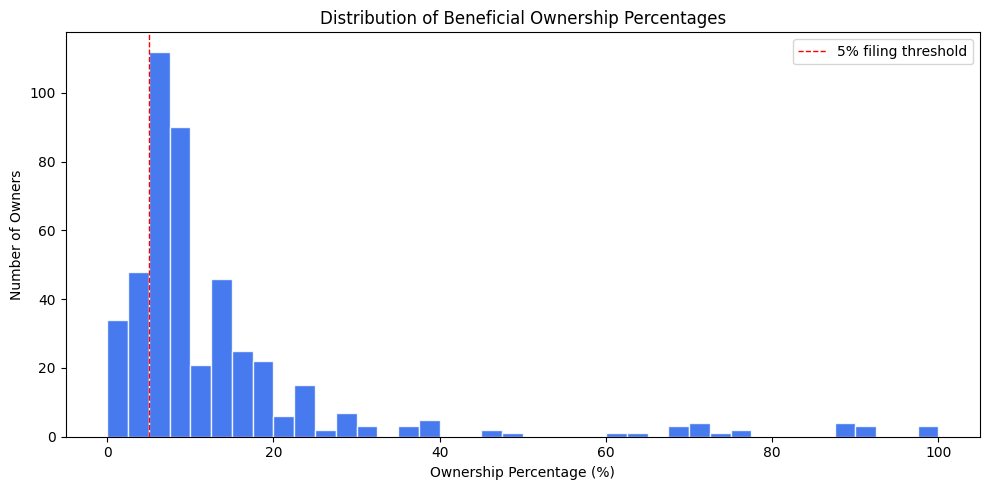

In [15]:
# Distribution of ownership percentages
fig, ax = plt.subplots(figsize=(10, 5))

pct_data = owners_df["amountAsPercent"].dropna()
pct_data = pct_data[(pct_data > 0) & (pct_data <= 100)]

ax.hist(pct_data, bins=40, edgecolor="white", color="#2563eb", alpha=0.85)
ax.set_xlabel("Ownership Percentage (%)")
ax.set_ylabel("Number of Owners")
ax.set_title("Distribution of Beneficial Ownership Percentages")
ax.axvline(x=5, color="red", linestyle="--", linewidth=1, label="5% filing threshold")
ax.legend()
plt.tight_layout()
plt.show()

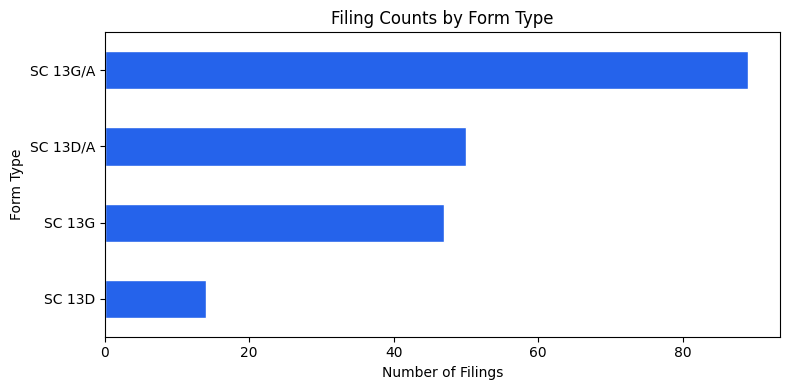

In [16]:
# Filing counts by form type
fig, ax = plt.subplots(figsize=(8, 4))

form_type_counts_sorted = form_type_counts.sort_values()
form_type_counts_sorted.plot(kind="barh", ax=ax, color="#2563eb", edgecolor="white")
ax.set_xlabel("Number of Filings")
ax.set_ylabel("Form Type")
ax.set_title("Filing Counts by Form Type")
plt.tight_layout()
plt.show()

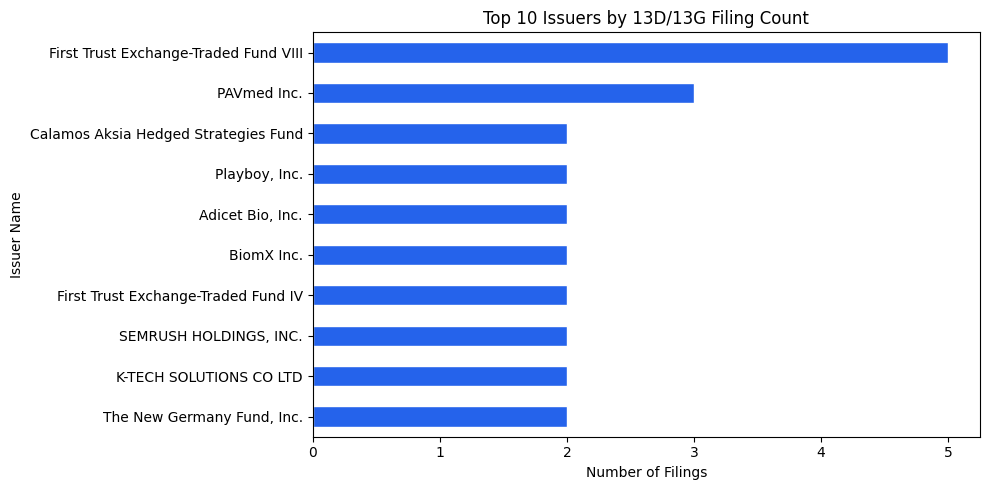

In [17]:
# Top 10 issuers by filing count
fig, ax = plt.subplots(figsize=(10, 5))

top_issuers_sorted = top_issuers.sort_values()
top_issuers_sorted.plot(kind="barh", ax=ax, color="#2563eb", edgecolor="white")
ax.set_xlabel("Number of Filings")
ax.set_ylabel("Issuer Name")
ax.set_title("Top 10 Issuers by 13D/13G Filing Count")
plt.tight_layout()
plt.show()

## Voting Power vs. Dispositive Power

A key feature of 13D/13G filings is the breakdown of voting power and dispositive (investment) power. **Voting power** is the right to vote or direct the voting of shares. **Dispositive power** is the right to sell, transfer, or otherwise dispose of shares. An owner can hold sole or shared variants of each.

In most cases, voting and dispositive power are equal — the owner who can sell the shares can also vote them. However, divergences reveal situations where voting rights have been separated from economic ownership, such as voting agreements, proxy arrangements, or securities lending. The scatter plot below highlights these patterns.

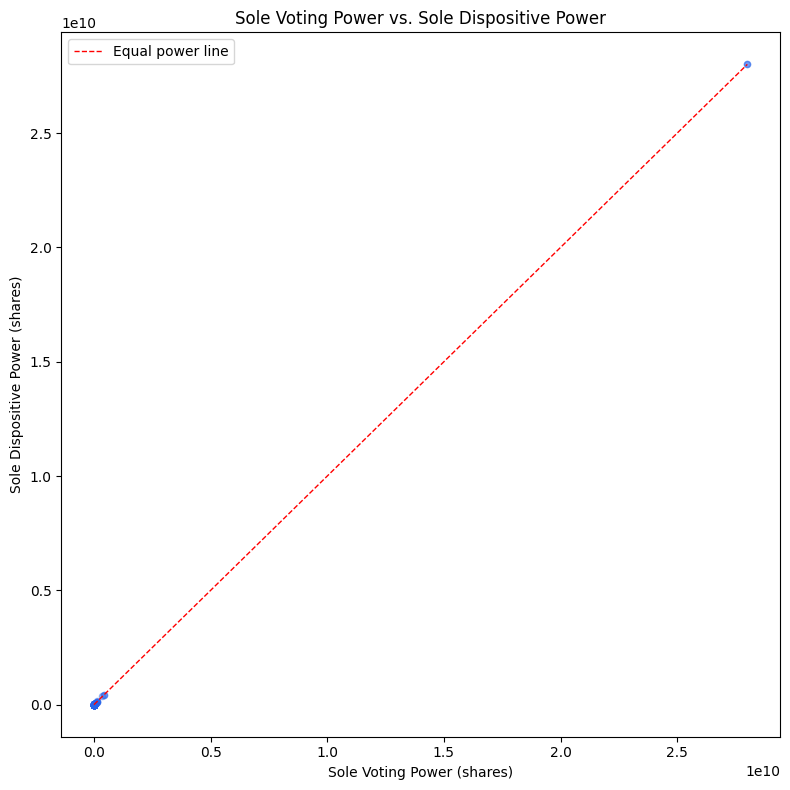

In [18]:
# Scatter plot: sole voting power vs. sole dispositive power
fig, ax = plt.subplots(figsize=(8, 8))

# Convert to numeric and filter out zero-value pairs
scatter_df = owners_df[["soleVotingPower", "soleDispositivePower"]].copy()
scatter_df["soleVotingPower"] = pd.to_numeric(scatter_df["soleVotingPower"], errors="coerce")
scatter_df["soleDispositivePower"] = pd.to_numeric(scatter_df["soleDispositivePower"], errors="coerce")
scatter_df = scatter_df.dropna()
scatter_df = scatter_df[(scatter_df["soleVotingPower"] > 0) | (scatter_df["soleDispositivePower"] > 0)]

ax.scatter(
    scatter_df["soleVotingPower"],
    scatter_df["soleDispositivePower"],
    alpha=0.4,
    s=20,
    color="#2563eb"
)

# Add diagonal reference line
max_val = max(scatter_df["soleVotingPower"].max(), scatter_df["soleDispositivePower"].max())
ax.plot([0, max_val], [0, max_val], color="red", linestyle="--", linewidth=1, label="Equal power line")

ax.set_xlabel("Sole Voting Power (shares)")
ax.set_ylabel("Sole Dispositive Power (shares)")
ax.set_title("Sole Voting Power vs. Sole Dispositive Power")
ax.legend()
plt.tight_layout()
plt.show()

## Exporting Results

Save the filing-level and owner-level DataFrames to CSV files for further analysis in other tools or for building downstream models.

In [19]:
df.to_csv("form_13d_13g_filings.csv", index=False)
owners_df.to_csv("form_13d_13g_owners.csv", index=False)

print(f"Exported {len(df)} filings to form_13d_13g_filings.csv")
print(f"Exported {len(owners_df)} owner records to form_13d_13g_owners.csv")

Exported 200 filings to form_13d_13g_filings.csv
Exported 513 owner records to form_13d_13g_owners.csv


## Further Reading

- [SEC Investor.gov: Schedules 13D and 13G](https://www.sec.gov/answers/sched13.htm)
- [SEC Release No. 33-11253 — 2023 Modernization of Beneficial Ownership Reporting](https://www.sec.gov/rules-regulations/2023/10/33-11180)
- [sec-api.io Form 13D/13G API Documentation](https://sec-api.io/docs/form-13d-13g-search-api)
- [sec-api.io Python Examples](https://sec-api.io/docs/form-13d-13g-search-api/python-examples)
- [SEC C&DI: Regulation 13D-G Beneficial Ownership Reporting](https://www.sec.gov/rules-regulations/staff-guidance/corporation-finance-interpretations/exchange-act-sections-13d-13g-regulation-13d-g-beneficial-ownership-reporting)